In [2]:
import sys, subprocess

packages = [
    "torch",
    "torchvision",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "Pillow",
    "numpy",
    "grad-cam",
    "shap",
    "codecarbon",
]

for pkg in packages:
    print

In [4]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (classification_report,
    confusion_matrix, accuracy_score, f1_score)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

FIG = 'results/figures'
TAB = 'results/tables'
os.makedirs(FIG, exist_ok=True)
os.makedirs(TAB, exist_ok=True)

def save_fig(name):
    plt.savefig(f'{FIG}/{name}.pdf',
                bbox_inches='tight', dpi=300)
    plt.savefig(f'{FIG}/{name}.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved → {FIG}/{name}.pdf')

def save_csv(df, name):
    df.to_csv(f'{TAB}/{name}.csv', index=True)
    print(f'Saved → {TAB}/{name}.csv')

CLASSES = ['cardboard','glass','metal',
           'other','paper','plastic']
DEVICE  = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Device: cpu | PyTorch: 2.12.0+cpu


In [5]:
import urllib.request, zipfile, shutil, pathlib

BASE  = pathlib.Path('data')
TRAIN = BASE / 'train'
TRAIN.mkdir(parents=True, exist_ok=True)

URL = ('https://github.com/garythung/trashnet'
       '/raw/master/data/dataset-resized.zip')
ZIP = BASE / 'dataset-resized.zip'

if not any(TRAIN.iterdir()):
    if not ZIP.exists():
        print('Downloading TrashNet (~55 MB)...')
        urllib.request.urlretrieve(URL, ZIP)
    print('Extracting...')
    with zipfile.ZipFile(ZIP, 'r') as z:
        z.extractall(BASE)
    EXTRACTED = BASE / 'dataset-resized'
    for src, dst in [
        ('glass','glass'),('paper','paper'),
        ('cardboard','cardboard'),
        ('plastic','plastic'),
        ('metal','metal'),('trash','other')]:
        s = EXTRACTED/src; d = TRAIN/dst
        if s.exists() and not d.exists():
            shutil.copytree(s, d)

classes = sorted(os.listdir(TRAIN))
counts  = {c: len(os.listdir(TRAIN/c))
           for c in classes}
print('\n✅ Dataset ready:')
for c,n in counts.items():
    print(f'   {c:12s} {n} images')
print(f'   Total: {sum(counts.values())}')


✅ Dataset ready:
   cardboard    403 images
   glass        501 images
   metal        410 images
   other        137 images
   paper        594 images
   plastic      482 images
   Total: 2527


In [6]:
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225])
])

full_ds = datasets.ImageFolder(
    'data/train', transform=transform_train)
n_val   = int(0.2 * len(full_ds))
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED))
val_ds.dataset.transform = transform_val

train_loader = DataLoader(
    train_ds, batch_size=32,
    shuffle=True, num_workers=0)
val_loader = DataLoader(
    val_ds, batch_size=32,
    shuffle=False, num_workers=0)

CLASS_NAMES = full_ds.classes
print(f'Train:{n_train}  Val:{n_val}')
print(f'Classes: {CLASS_NAMES}')

Train:2022  Val:505
Classes: ['cardboard', 'glass', 'metal', 'other', 'paper', 'plastic']


In [7]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT)
for param in list(model.parameters())[:-20]:
    param.requires_grad = False
model.fc = nn.Linear(
    model.fc.in_features, len(CLASS_NAMES))
model = model.to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad,
           model.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.5)
criterion = nn.CrossEntropyLoss()
trainable = sum(p.numel()
    for p in model.parameters()
    if p.requires_grad)
print(f'Model ready | Trainable: {trainable:,}')

Model ready | Trainable: 8,937,478


In [9]:
EPOCHS = 5
history = {'train_loss':[],'val_loss':[],
           'train_acc':[],'val_acc':[]}

for epoch in range(EPOCHS):
    model.train()
    tr_loss,tr_correct,tr_total = 0,0,0
    for imgs,labels in train_loader:
        imgs,labels = (imgs.to(DEVICE),
                       labels.to(DEVICE))
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        tr_loss    += loss.item()*imgs.size(0)
        tr_correct += (out.argmax(1)==labels
                       ).sum().item()
        tr_total   += imgs.size(0)
    model.eval()
    vl_loss,vl_correct,vl_total = 0,0,0
    with torch.no_grad():
        for imgs,labels in val_loader:
            imgs,labels = (imgs.to(DEVICE),
                           labels.to(DEVICE))
            out  = model(imgs)
            loss = criterion(out, labels)
            vl_loss    += loss.item()*imgs.size(0)
            vl_correct += (out.argmax(1)==labels
                           ).sum().item()
            vl_total   += imgs.size(0)
    scheduler.step()
    ta=tr_correct/tr_total
    va=vl_correct/vl_total
    tl=tr_loss/tr_total
    vl=vl_loss/vl_total
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)
    print(f'Epoch {epoch+1}/{EPOCHS} '
          f'TrainAcc:{ta:.3f} ValAcc:{va:.3f}')

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(),
           'models/resnet50_waste.pth')
print('✅ Model saved')

Epoch 1/5 TrainAcc:0.992 ValAcc:0.891
Epoch 2/5 TrainAcc:0.992 ValAcc:0.893
Epoch 3/5 TrainAcc:0.997 ValAcc:0.897
Epoch 4/5 TrainAcc:0.992 ValAcc:0.901
Epoch 5/5 TrainAcc:0.997 ValAcc:0.897
✅ Model saved


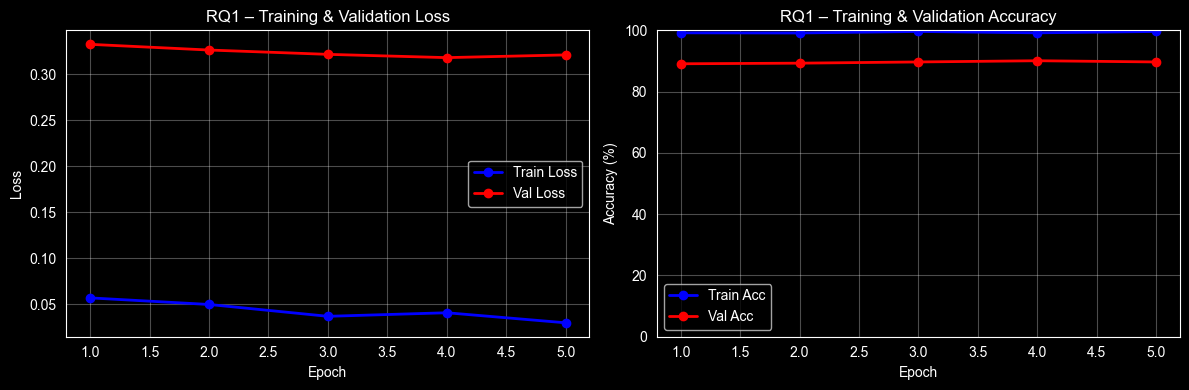

Saved → results/figures/rq1_training_curves.pdf
Saved → results/tables/rq1_training_history.csv


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
epochs = range(1, EPOCHS+1)

ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('RQ1 – Training & Validation Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', linewidth=2)
ax2.plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('RQ1 – Training & Validation Accuracy')
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim([0,100])

plt.tight_layout()
save_fig('rq1_training_curves')

df_hist = pd.DataFrame(history, index=range(1, EPOCHS+1))
df_hist.index.name = 'epoch'
save_csv(df_hist, 'rq1_training_history')

In [11]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True)
df_report = pd.DataFrame(report).T.round(4)
print(classification_report(
    y_true, y_pred, target_names=CLASS_NAMES))
save_csv(df_report, 'rq1_classification_report')

              precision    recall  f1-score   support

   cardboard       0.93      0.87      0.90        76
       glass       0.89      0.93      0.91       105
       metal       0.91      0.92      0.91        86
       other       0.86      0.72      0.78        25
       paper       0.90      0.94      0.92       121
     plastic       0.87      0.85      0.86        92

    accuracy                           0.90       505
   macro avg       0.89      0.87      0.88       505
weighted avg       0.90      0.90      0.90       505

Saved → results/tables/rq1_classification_report.csv


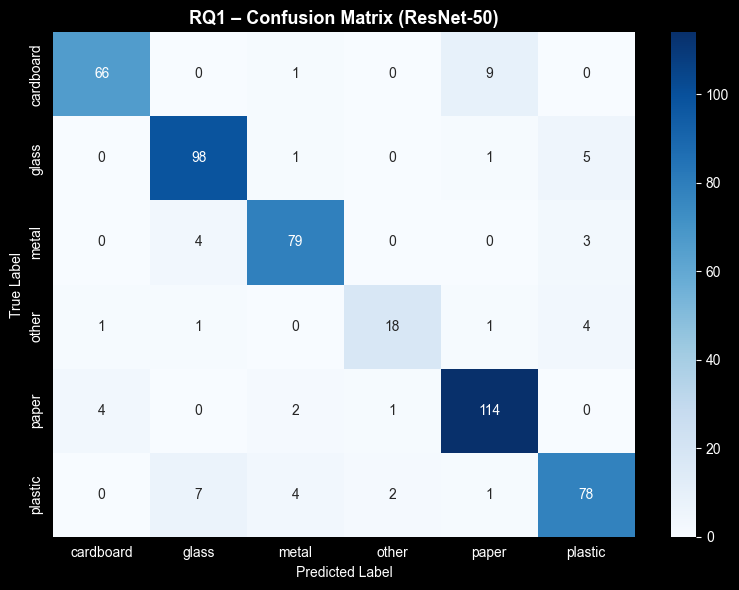

Saved → results/figures/rq1_confusion_matrix.pdf


In [12]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('RQ1 – Confusion Matrix (ResNet-50)',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
save_fig('rq1_confusion_matrix')

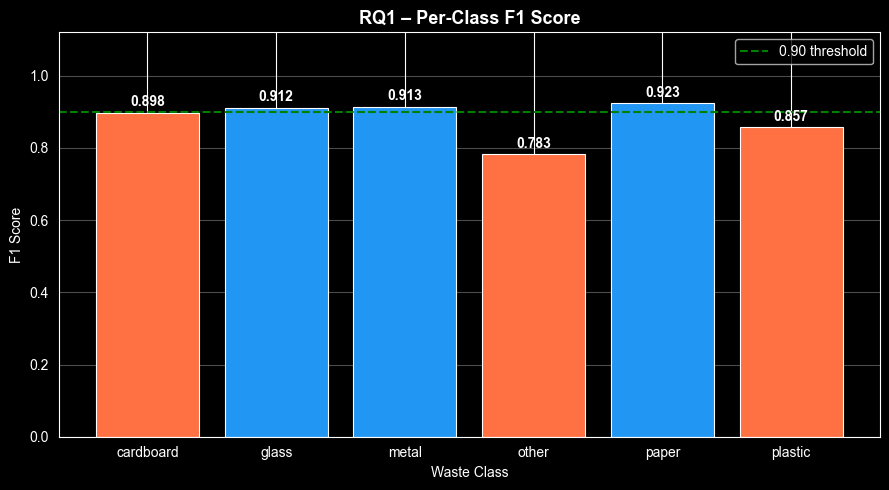

Saved → results/figures/rq1_f1_per_class.pdf
Saved → results/tables/rq1_f1_scores.csv


In [13]:
f1_scores = {cls: report[cls]['f1-score']
             for cls in CLASS_NAMES}
colors = ['#2196F3' if v >= 0.90 else '#FF7043'
          for v in f1_scores.values()]

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(f1_scores.keys(),
              f1_scores.values(),
              color=colors,
              edgecolor='white', linewidth=0.8)
ax.axhline(y=0.90, color='green',
    linestyle='--', linewidth=1.5,
    label='0.90 threshold')
for bar, val in zip(bars, f1_scores.values()):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01,
            f'{val:.3f}', ha='center',
            va='bottom', fontsize=10,
            fontweight='bold')
ax.set_title('RQ1 – Per-Class F1 Score',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Waste Class')
ax.set_ylabel('F1 Score')
ax.set_ylim([0, 1.12])
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig('rq1_f1_per_class')

df_f1 = pd.DataFrame(
    list(f1_scores.items()),
    columns=['Class','F1_Score'])
save_csv(df_f1, 'rq1_f1_scores')

In [14]:
acc = accuracy_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average='macro')
print('='*50)
print('RQ1 RESULTS SUMMARY')
print('='*50)
print(f'Overall Accuracy : {acc*100:.2f}%')
print(f'Macro F1 Score   : {f1m:.4f}')
print(f'Best class  : '
      f'{max(f1_scores, key=f1_scores.get)} '
      f'(F1={max(f1_scores.values()):.3f})')
print(f'Hardest class: '
      f'{min(f1_scores, key=f1_scores.get)} '
      f'(F1={min(f1_scores.values()):.3f})')
print('RQ1 COMPLETE ✅')

RQ1 RESULTS SUMMARY
Overall Accuracy : 89.70%
Macro F1 Score   : 0.8810
Best class  : paper (F1=0.923)
Hardest class: other (F1=0.783)
RQ1 COMPLETE ✅
